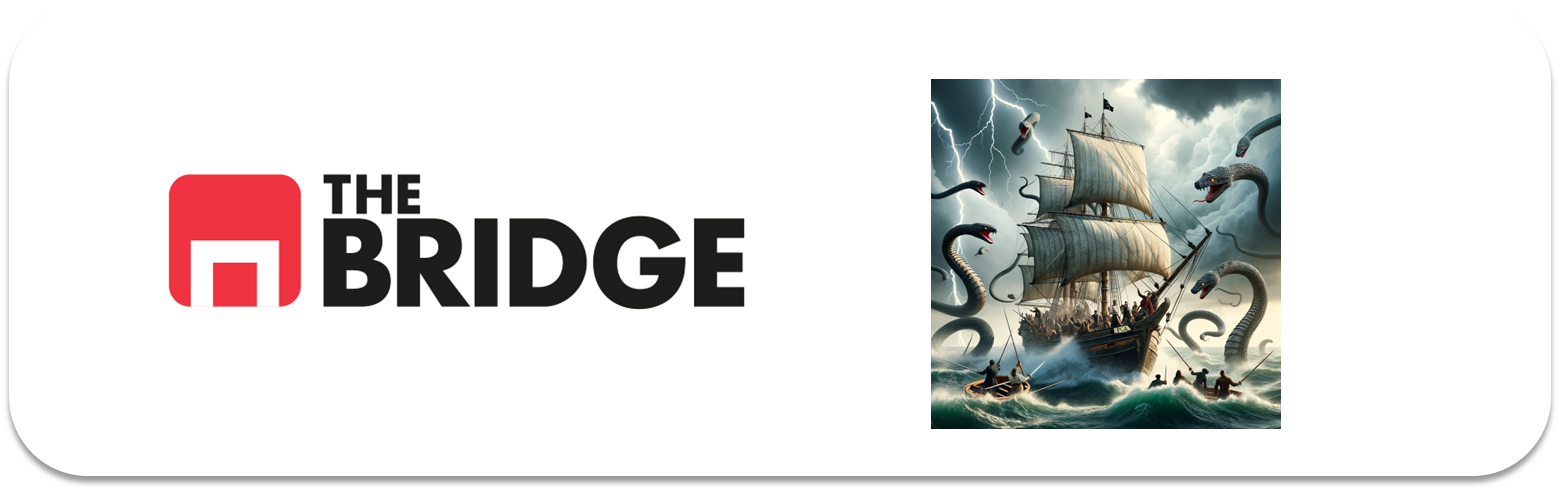

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import bootcampviztools as bvt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif,
    SelectFromModel, RFE, SequentialFeatureSelector
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import recall_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [2]:
df = pd.read_csv("./data/credit_npo.csv")

print("Dimensiones:", df.shape)
print("\nNulos por columna:")
print(df.isna().sum())
df.head()

Dimensiones: (12537, 11)

Nulos por columna:
SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


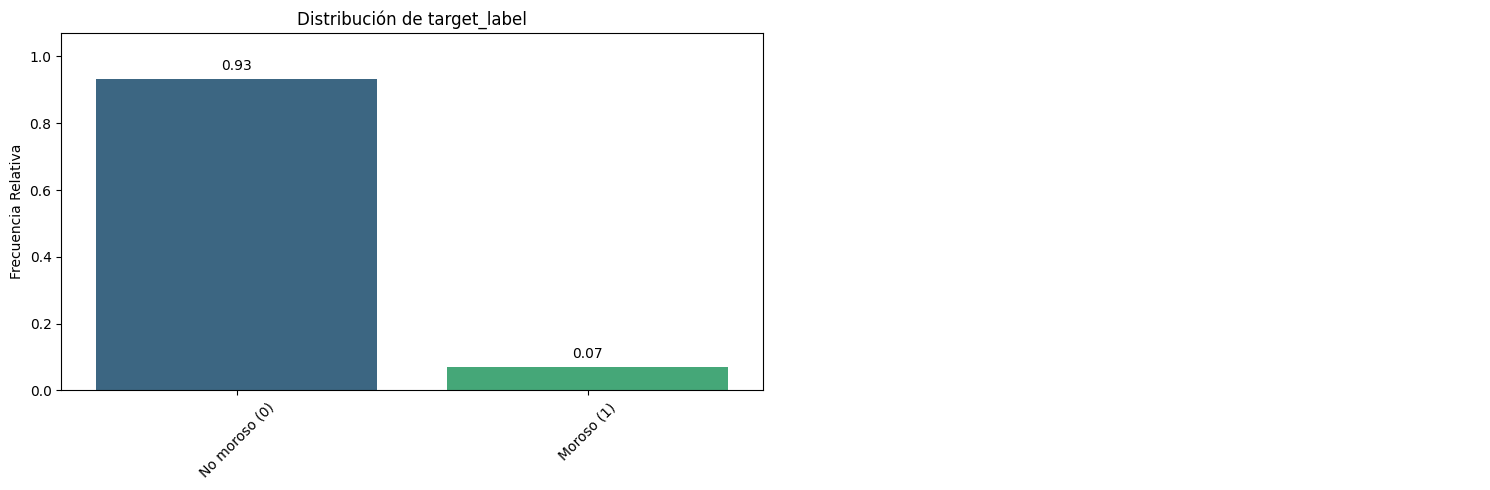

{0: 0.931, 1: 0.069}


In [3]:
# Distribucion del target: clase muy desbalanceada
# Creamos una version con etiquetas legibles para los graficos
target = "SeriousDlqin2yrs"
df["target_label"] = df[target].map({0: "No moroso (0)", 1: "Moroso (1)"})

# Lo vemos con un grafico de barras (frecuencia relativa) del modulo de visualizaciones
bvt.pinta_distribucion_categoricas(df, ["target_label"], relativa=True, mostrar_valores=True)

# Y el porcentaje exacto
print(df[target].value_counts(normalize=True).round(3).to_dict())

In [4]:
# Quitamos las filas con nulos
df = df.dropna().reset_index(drop=True)
print("Tras eliminar nulos:", df.shape)

# Convertimos las NumberOf... a categoricas de 3 niveles: 0 / 1-2 / 3+
def a_categorica(serie):
    return pd.cut(serie, bins=[-1, 0, 2, np.inf], labels=["0", "1-2", "3+"])

conversiones = {
    "NumberOfTime30-59DaysPastDueNotWorse": "cat_30_59",
    "NumberOfTimes90DaysLate": "cat_90",
    "NumberOfTime60-89DaysPastDueNotWorse": "cat_60_89",
    "NumberRealEstateLoansOrLines": "cat_realestate",
    "NumberOfDependents": "cat_dependents",
}

for original, nueva in conversiones.items():
    df[nueva] = a_categorica(df[original])

# Eliminamos las originales ya convertidas
df = df.drop(columns=list(conversiones.keys()))

# Definimos las listas de columnas numericas y categoricas
num_cols = ["RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio",
            "MonthlyIncome", "NumberOfOpenCreditLinesAndLoans"]
cat_cols = ["cat_30_59", "cat_90", "cat_60_89", "cat_realestate", "cat_dependents"]

print("Numericas:", num_cols)
print("Categoricas:", cat_cols)
df.head()

Tras eliminar nulos: (11816, 12)
Numericas: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']
Categoricas: ['cat_30_59', 'cat_90', 'cat_60_89', 'cat_realestate', 'cat_dependents']


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,target_label,cat_30_59,cat_90,cat_60_89,cat_realestate,cat_dependents
0,0,0.081892,37,0.070709,5656.0,12,No moroso (0),0,1-2,0,0,0
1,0,0.023413,74,0.209197,4870.0,9,No moroso (0),0,0,0,1-2,0
2,0,0.000000,43,0.080784,5000.0,2,No moroso (0),0,0,0,0,1-2
3,0,0.492754,44,0.412735,7333.0,4,No moroso (0),0,0,0,1-2,3+
4,0,1.000000,63,0.000000,8333.0,3,No moroso (0),0,0,0,0,1-2


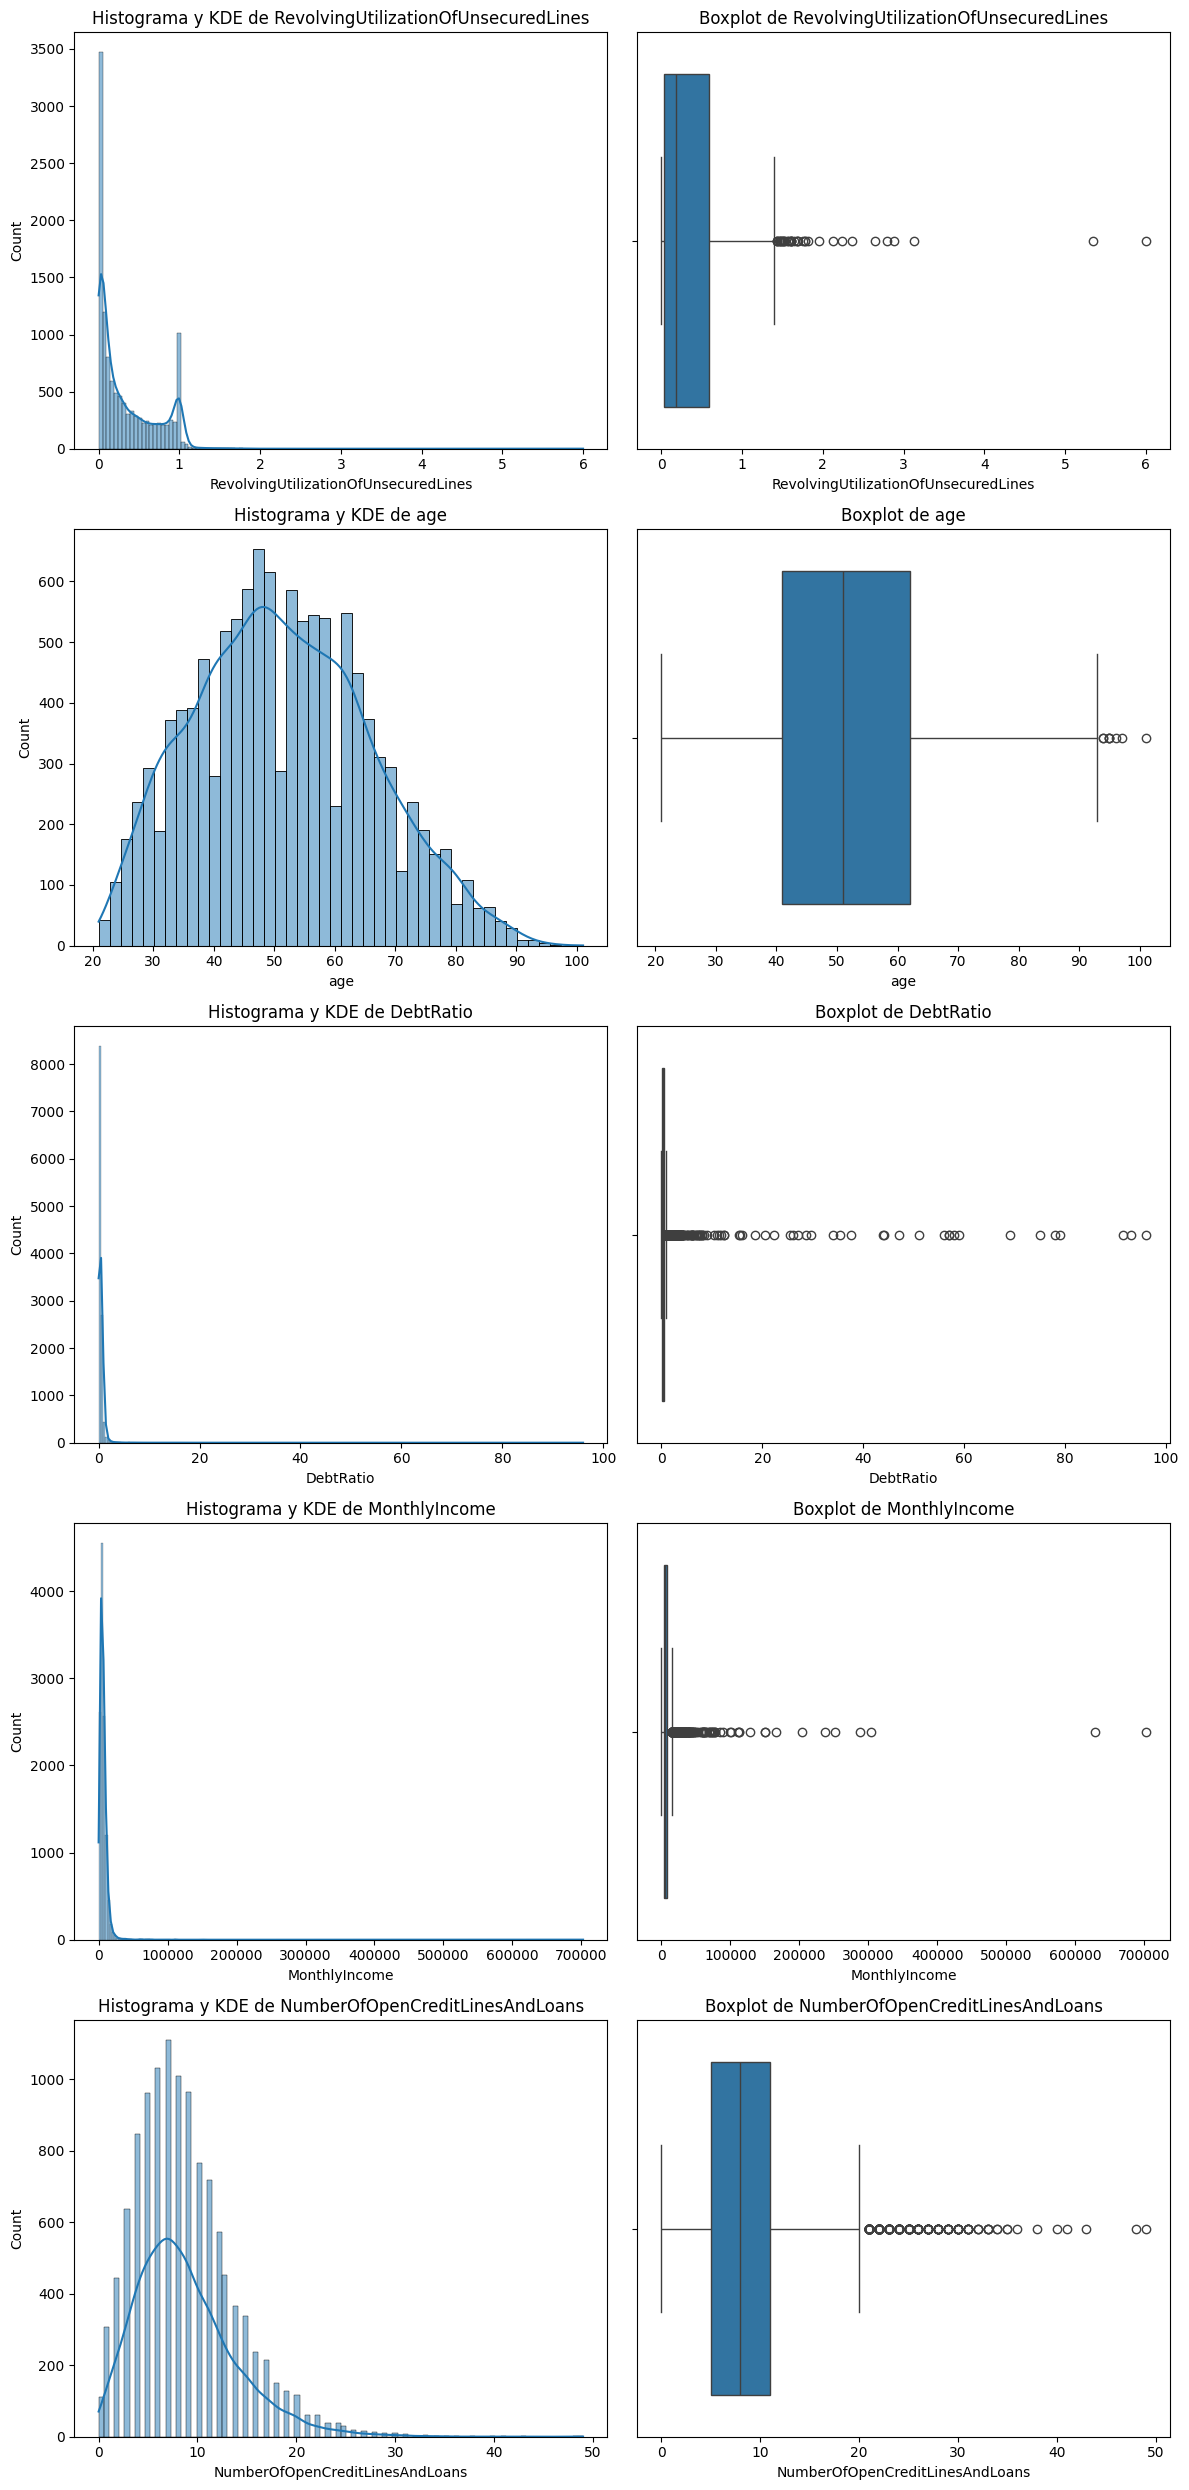

In [5]:
# Distribucion de las numericas: histograma + KDE y boxplot
bvt.plot_combined_graphs(df, num_cols)

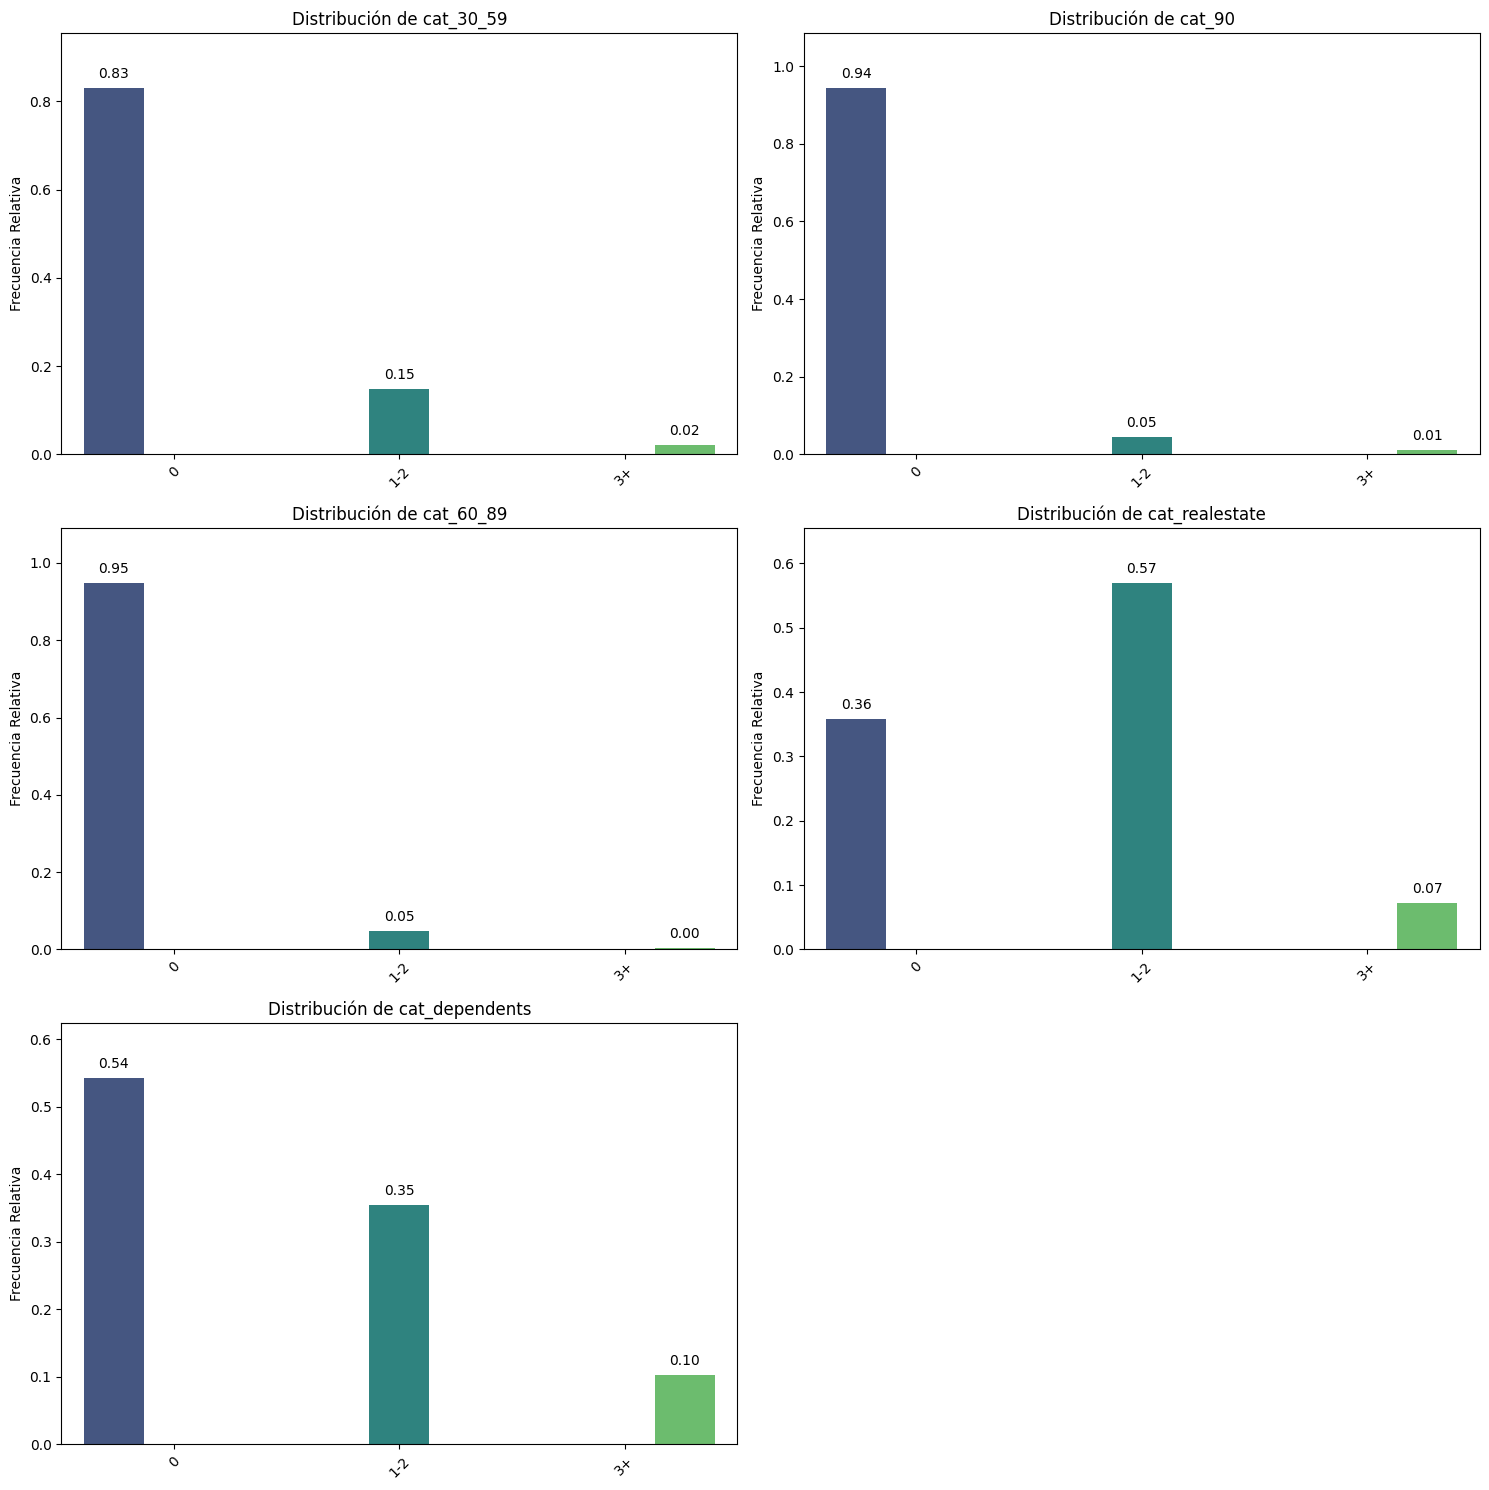

In [6]:
# Reparto de las categoricas creadas
bvt.pinta_distribucion_categoricas(df, cat_cols, relativa=True, mostrar_valores=True)

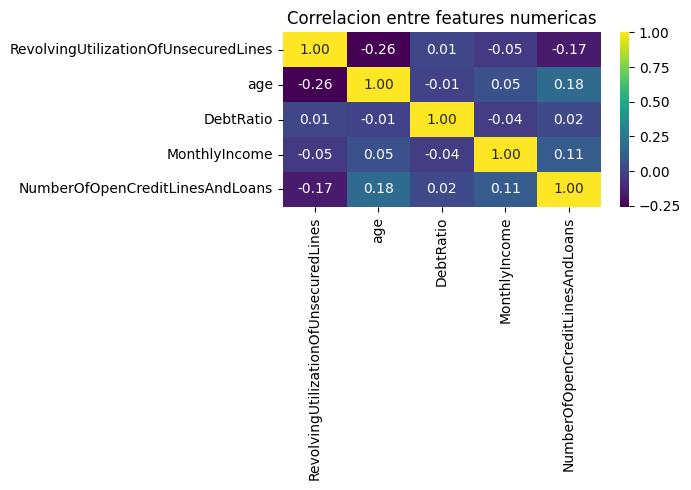

Varianza de cada numerica:
RevolvingUtilizationOfUnsecuredLines    1.300000e-01
age                                     2.107200e+02
DebtRatio                               7.270000e+00
MonthlyIncome                           1.405625e+08
NumberOfOpenCreditLinesAndLoans         2.631000e+01
dtype: float64


In [7]:
# Correlacion entre numericas para filtrar redundancias
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlacion entre features numericas")
plt.tight_layout()
plt.show()

# Covarianza (magnitud de la variacion conjunta)
print("Varianza de cada numerica:")
print(df[num_cols].var().round(2))

Las numéricas están poco correlacionadas entre sí (no hay pares casi idénticos que haya que descartar). De este análisis visual + correlación nos quedamos con una **lista 1** razonable: las numéricas más informativas del boxplot/histograma junto con las categóricas de morosidad (`cat_90`, `cat_30_59`, `cat_60_89`), que son las que más separan el target.

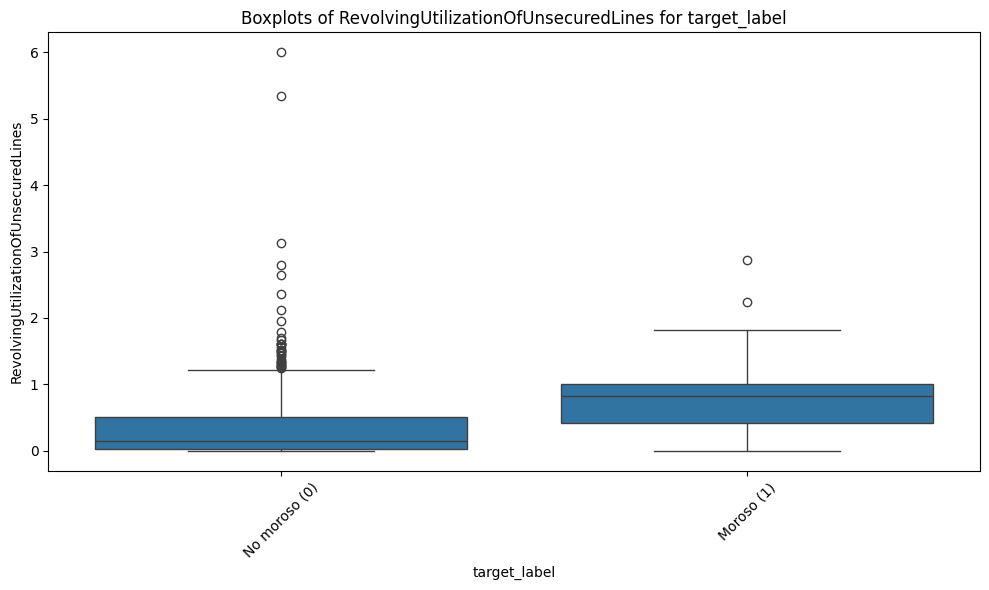

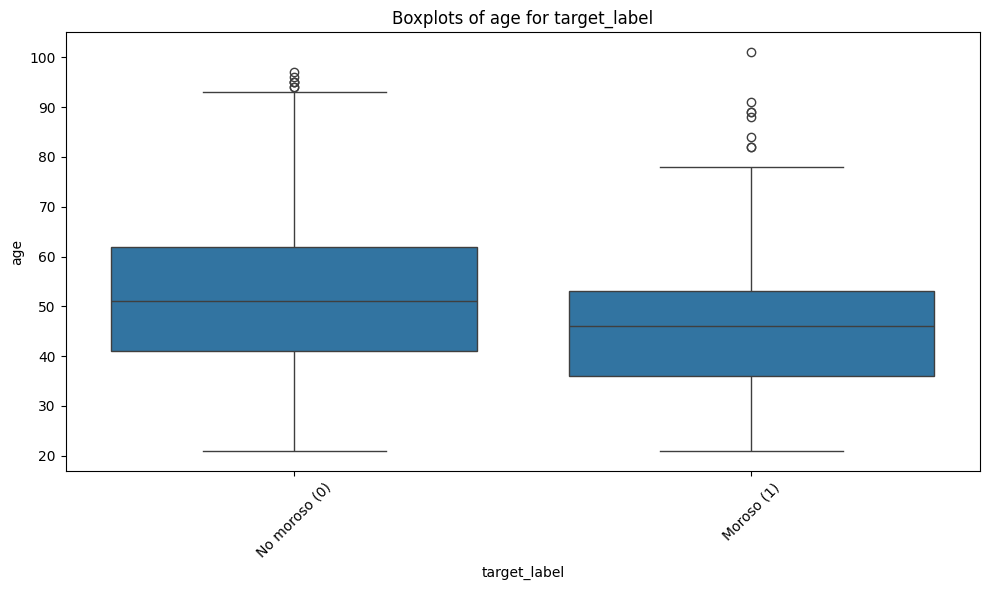

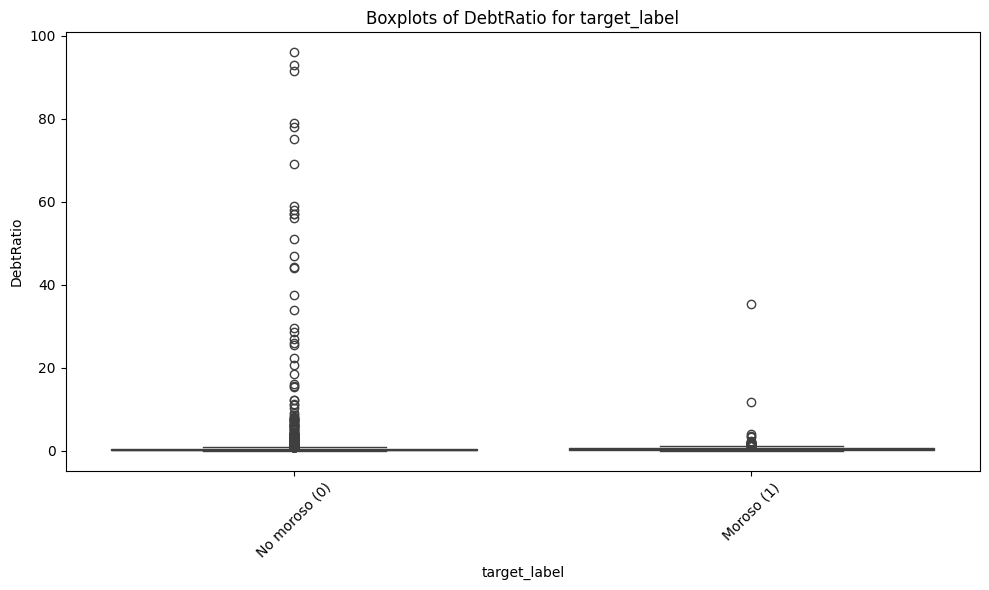

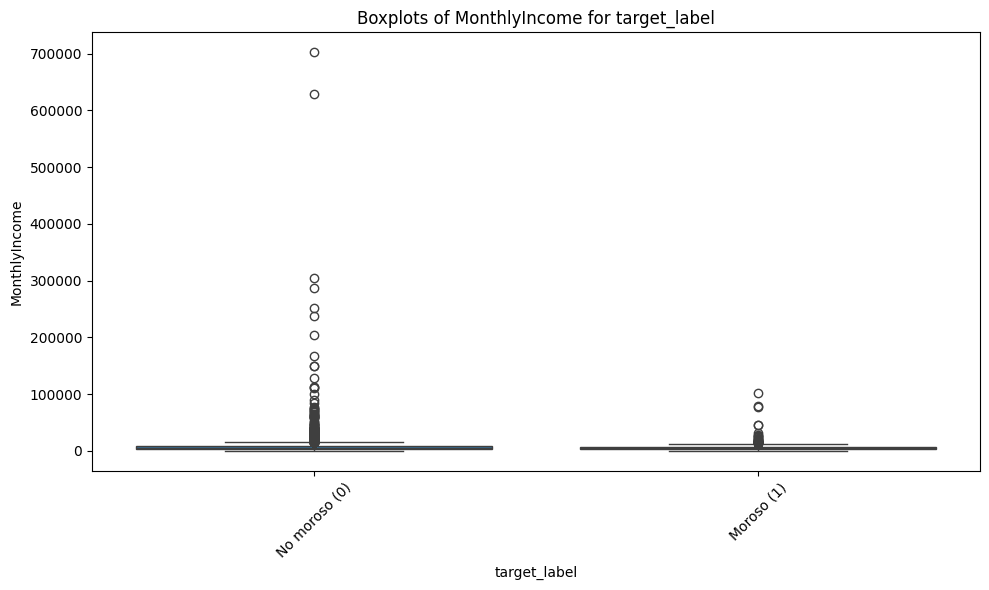

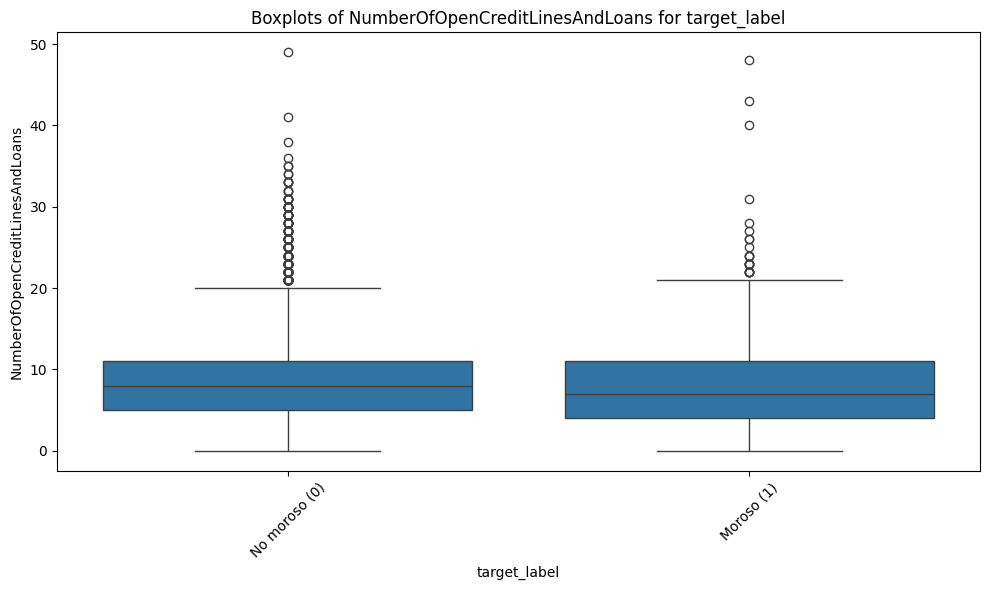

In [8]:
# Numericas frente al target: boxplot agrupado por morosidad
for col in num_cols:
    bvt.plot_grouped_boxplots(df, "target_label", col)

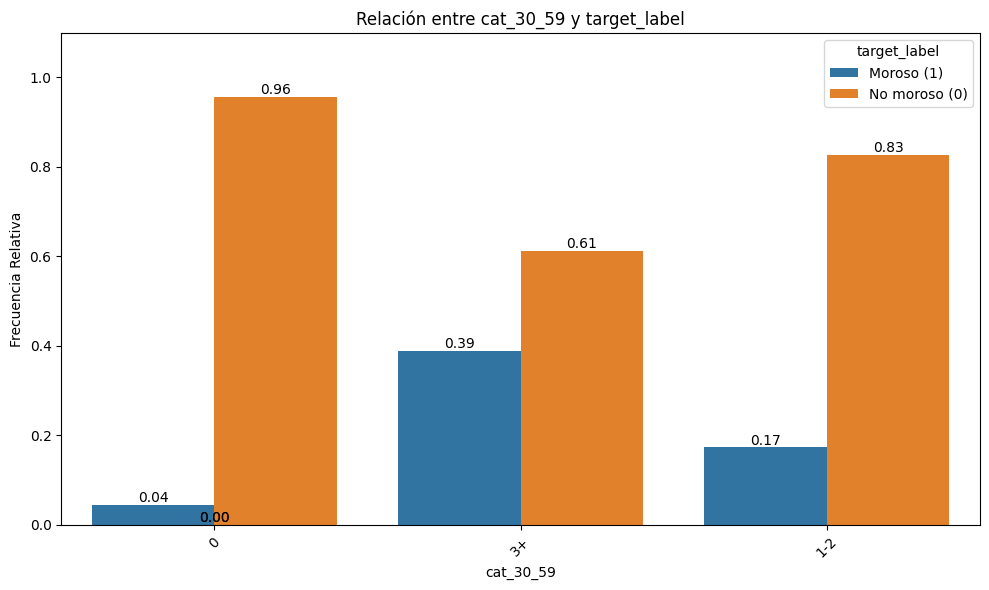

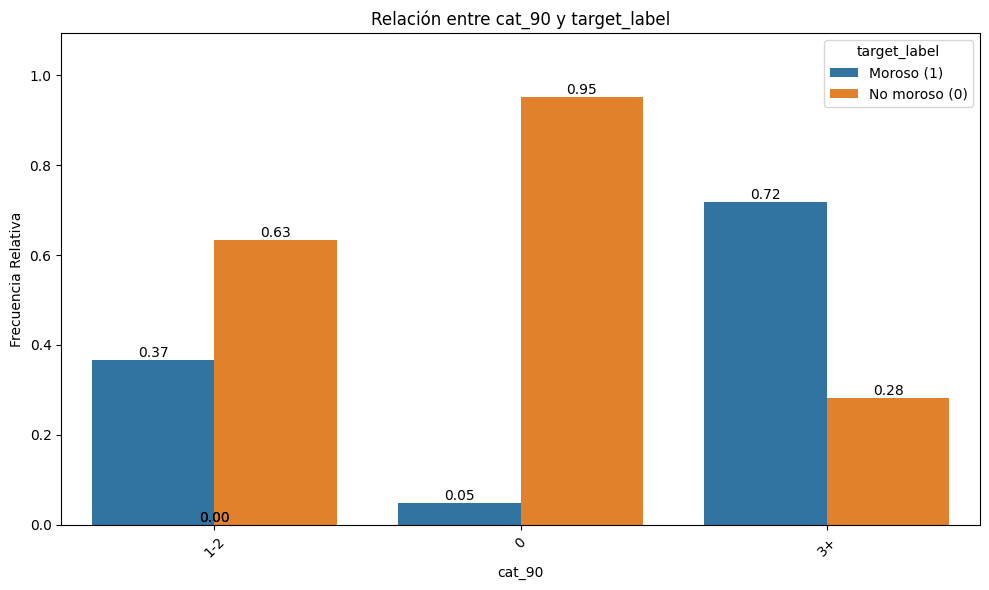

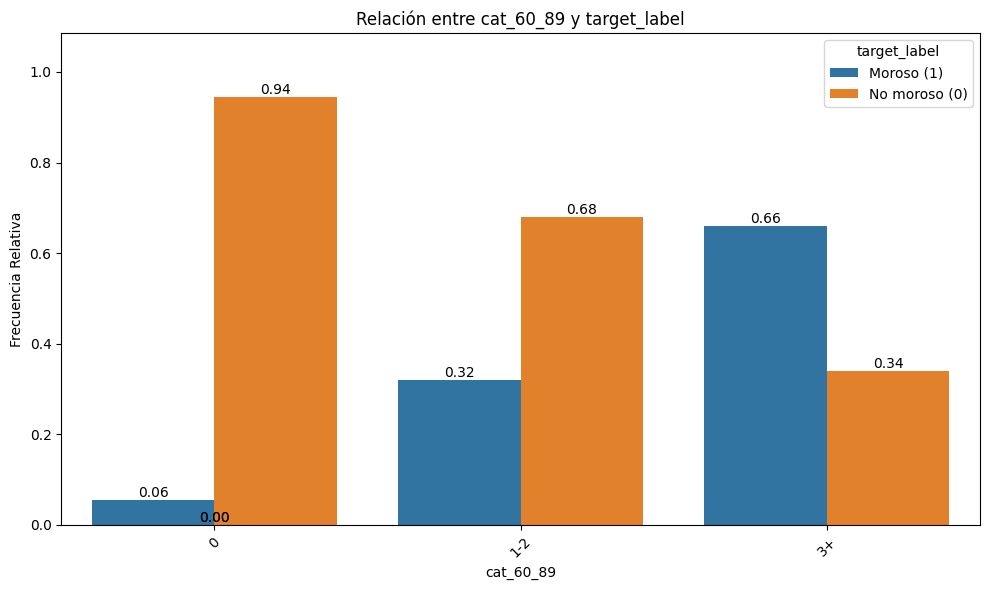

In [9]:
# Categoricas de morosidad frente al target: frecuencia relativa
# (si la proporcion de "Moroso" cambia mucho entre niveles, la feature discrimina)
for col in ["cat_30_59", "cat_90", "cat_60_89"]:
    bvt.plot_categorical_relationship(df, col, "target_label",
                                      relative_freq=True, show_values=True)

Se ve que las categóricas de morosidad (`cat_30_59`, `cat_90`, `cat_60_89`) discriminan con fuerza: en los niveles `1-2` y `3+` la proporción de morosos se dispara respecto al nivel `0`. Entre las numéricas, `RevolvingUtilizationOfUnsecuredLines` y la edad son las que más se separan. Esto anticipa las features que dominarán las listas de selección.

**Split train/test** (estratificado por el target, que está muy desbalanceado). Se mantiene para toda la práctica. Escalamos las numéricas para los métodos que lo necesitan (RFE, SFS, regresión logística).

In [10]:
# One-hot de las categoricas para poder modelar
X = pd.get_dummies(df.drop(columns=[target, "target_label"]), columns=cat_cols, drop_first=True)
y = df[target]

# Split estratificado (la clase esta desbalanceada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Escalado (fit solo en train)
scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Columnas categoricas ya codificadas (para MI)
cat_encoded = [c for c in X_train.columns if c.startswith("cat_")]

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (9452, 15)  Test: (2364, 15)


**Técnicas de selección de features**

Vamos a generar **6 listas** de features (máximo 6 variables cada una). Guardamos todas en un diccionario `listas`.

_Lista 1 — Análisis visual + correlación/covarianza_ (la que hemos razonado arriba)

In [11]:
listas = {}

# Lista 1: del analisis visual + correlacion (numericas informativas + morosidad)
listas["visual_corr"] = [
    "RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio",
    "cat_90_1-2", "cat_30_59_1-2", "cat_60_89_1-2",
]
listas["visual_corr"]

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'cat_90_1-2',
 'cat_30_59_1-2',
 'cat_60_89_1-2']

_Lista 2 — SelectKBest + ANOVA (numéricas) y Mutual Information (categóricas)_

In [12]:
# Numericas: SelectKBest con ANOVA (f_classif), nos quedamos con las 3 mejores
skb = SelectKBest(f_classif, k=3).fit(X_train[num_cols], y_train)
anova_feats = list(np.array(num_cols)[skb.get_support()])

# Categoricas: Mutual Information, nos quedamos con las 3 mejores
mi_scores = mutual_info_classif(X_train[cat_encoded], y_train, random_state=42)
mi_serie = pd.Series(mi_scores, index=cat_encoded).sort_values(ascending=False)
mi_feats = mi_serie.head(3).index.tolist()

listas["anova_mi"] = anova_feats + mi_feats
print("ANOVA (numericas):", anova_feats)
print("MI (categoricas):", mi_feats)
listas["anova_mi"]

ANOVA (numericas): [np.str_('RevolvingUtilizationOfUnsecuredLines'), np.str_('age'), np.str_('NumberOfOpenCreditLinesAndLoans')]
MI (categoricas): ['cat_90_1-2', 'cat_60_89_1-2', 'cat_90_3+']


[np.str_('RevolvingUtilizationOfUnsecuredLines'),
 np.str_('age'),
 np.str_('NumberOfOpenCreditLinesAndLoans'),
 'cat_90_1-2',
 'cat_60_89_1-2',
 'cat_90_3+']

_Lista 3 — SelectFromModel_ (un RandomForest como modelo intermedio, nos quedamos con las de mayor importancia)

In [13]:
# SelectFromModel con un RandomForest (max 6 features)
sfm = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
    max_features=6,
).fit(X_train_s, y_train)

listas["sfm"] = list(X_train.columns[sfm.get_support()])[:6]
listas["sfm"]

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans']

_Lista 4 — RFE_ (eliminación recursiva con regresión logística)

In [14]:
# RFE: eliminacion recursiva hasta quedarnos con 6 features
rfe = RFE(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    n_features_to_select=6,
).fit(X_train_s, y_train)

listas["rfe"] = list(X_train.columns[rfe.get_support()])
listas["rfe"]

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'cat_30_59_1-2',
 'cat_90_1-2',
 'cat_90_3+',
 'cat_60_89_1-2']

_Lista 5 — SFS_ (selección secuencial hacia delante, optimizando recall)

In [15]:
# SFS: seleccion secuencial hacia delante (forward), 6 features, scoring recall
sfs = SequentialFeatureSelector(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    n_features_to_select=6,
    direction="forward",
    scoring="recall",
    cv=3,
).fit(X_train_s, y_train)

listas["sfs"] = list(X_train.columns[sfs.get_support()])
listas["sfs"]

['RevolvingUtilizationOfUnsecuredLines',
 'DebtRatio',
 'NumberOfOpenCreditLinesAndLoans',
 'cat_30_59_3+',
 'cat_60_89_1-2',
 'cat_dependents_1-2']

_Lista 6 — Hard-voting_ sobre las listas 1 a 5: contamos cuántas veces aparece cada feature y nos quedamos con las 6 más votadas.

In [16]:
# Hard-voting: contamos apariciones de cada feature en las listas 1-5
votos = Counter()
for nombre, feats in listas.items():
    votos.update(feats)

listas["voting"] = [f for f, _ in votos.most_common(6)]

print("Votos por feature:")
for f, n in votos.most_common():
    print(f"  {n}  {f}")
print("\nLista por voting:", listas["voting"])

Votos por feature:
  5  RevolvingUtilizationOfUnsecuredLines
  4  age
  4  cat_60_89_1-2
  3  DebtRatio
  3  cat_90_1-2
  3  NumberOfOpenCreditLinesAndLoans
  2  cat_30_59_1-2
  2  cat_90_3+
  1  MonthlyIncome
  1  cat_30_59_3+
  1  cat_dependents_1-2

Lista por voting: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'cat_60_89_1-2', 'DebtRatio', 'cat_90_1-2', np.str_('NumberOfOpenCreditLinesAndLoans')]


In [17]:
# Resumen de las 6 listas
for nombre, feats in listas.items():
    print(f"{nombre:>12}: {feats}")

 visual_corr: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'cat_90_1-2', 'cat_30_59_1-2', 'cat_60_89_1-2']
    anova_mi: [np.str_('RevolvingUtilizationOfUnsecuredLines'), np.str_('age'), np.str_('NumberOfOpenCreditLinesAndLoans'), 'cat_90_1-2', 'cat_60_89_1-2', 'cat_90_3+']
         sfm: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']
         rfe: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'cat_30_59_1-2', 'cat_90_1-2', 'cat_90_3+', 'cat_60_89_1-2']
         sfs: ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans', 'cat_30_59_3+', 'cat_60_89_1-2', 'cat_dependents_1-2']
      voting: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'cat_60_89_1-2', 'DebtRatio', 'cat_90_1-2', np.str_('NumberOfOpenCreditLinesAndLoans')]


In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    "logreg": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "random_forest": RandomForestClassifier(n_estimators=150, random_state=42, class_weight="balanced"),
    "grad_boosting": GradientBoostingClassifier(random_state=42),
}

filas = []
for nombre_modelo, modelo in modelos.items():
    for nombre_lista, feats in listas.items():
        score = cross_val_score(modelo, X_train_s[feats], y_train,
                                cv=cv, scoring="recall").mean()
        filas.append({"modelo": nombre_modelo, "lista": nombre_lista, "recall_cv": round(score, 3)})

resultados = pd.DataFrame(filas).sort_values("recall_cv", ascending=False).reset_index(drop=True)
resultados

,modelo,lista,recall_cv
0,logreg,sfs,0.747
1,logreg,voting,0.744
2,logreg,anova_mi,0.730
3,logreg,sfm,0.726
4,logreg,visual_corr,0.720
5,logreg,rfe,0.706
6,random_forest,rfe,0.223
7,random_forest,anova_mi,0.193
8,grad_boosting,anova_mi,0.188
9,grad_boosting,rfe,0.164


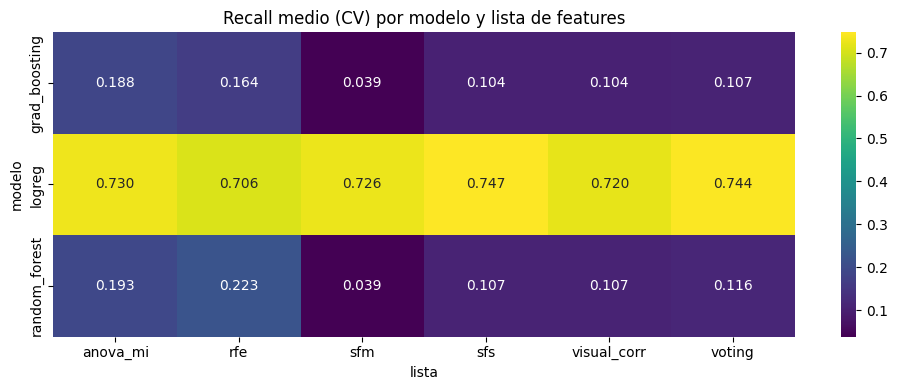

In [19]:
# Lo vemos tambien como tabla pivote (modelo x lista) para comparar de un vistazo
tabla = resultados.pivot(index="modelo", columns="lista", values="recall_cv")
plt.figure(figsize=(10, 4))
sns.heatmap(tabla, annot=True, cmap="viridis", fmt=".3f")
plt.title("Recall medio (CV) por modelo y lista de features")
plt.tight_layout()
plt.show()

In [20]:
# Mejor combinacion modelo + lista
mejor = resultados.iloc[0]
nombre_modelo_ganador = mejor["modelo"]
nombre_lista_ganadora = mejor["lista"]
feats_ganadoras = listas[nombre_lista_ganadora]

print("GANADOR")
print("  Modelo:", nombre_modelo_ganador)
print("  Lista :", nombre_lista_ganadora, "->", feats_ganadoras)
print("  Recall CV:", mejor["recall_cv"])

GANADOR
  Modelo: logreg
  Lista : sfs -> ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans', 'cat_30_59_3+', 'cat_60_89_1-2', 'cat_dependents_1-2']
  Recall CV: 0.747


In [21]:
# Optimizamos el modelo ganador con GridSearchCV sobre la mejor lista de features
X_train_best = X_train_s[feats_ganadoras]
X_test_best = X_test_s[feats_ganadoras]

if nombre_modelo_ganador == "logreg":
    modelo_base = LogisticRegression(max_iter=1000, class_weight="balanced")
    param_grid = {"C": [0.01, 0.1, 1, 10], "penalty": ["l2"]}
elif nombre_modelo_ganador == "random_forest":
    modelo_base = RandomForestClassifier(random_state=42, class_weight="balanced")
    param_grid = {"n_estimators": [100, 200], "max_depth": [4, 8, None],
                  "min_samples_leaf": [1, 5, 10]}
else:  # grad_boosting
    modelo_base = GradientBoostingClassifier(random_state=42)
    param_grid = {"n_estimators": [100, 200], "max_depth": [2, 3],
                  "learning_rate": [0.05, 0.1]}

grid = GridSearchCV(modelo_base, param_grid, cv=cv, scoring="recall", n_jobs=-1)
grid.fit(X_train_best, y_train)

print("Mejores hiperparametros:", grid.best_params_)
print("Mejor recall CV:", round(grid.best_score_, 3))

Mejores hiperparametros: {'C': 0.01, 'penalty': 'l2'}
Mejor recall CV: 0.75


Recall en test: 0.747

Informe de clasificacion:
              precision    recall  f1-score   support

           0       0.98      0.76      0.85      2198
           1       0.19      0.75      0.30       166

    accuracy                           0.76      2364
   macro avg       0.58      0.75      0.58      2364
weighted avg       0.92      0.76      0.81      2364



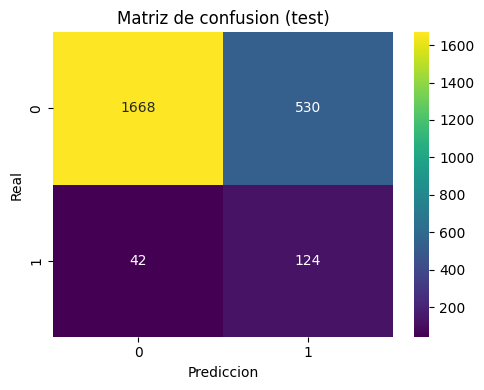

In [22]:
# Evaluacion contra test
mejor_modelo = grid.best_estimator_
y_pred = mejor_modelo.predict(X_test_best)

print("Recall en test:", round(recall_score(y_test, y_pred), 3))
print("\nInforme de clasificacion:")
print(classification_report(y_test, y_pred))

# Matriz de confusion
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="viridis")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de confusion (test)")
plt.tight_layout()
plt.show()

**Conclusión**

El mejor compromiso entre sencillez y potencia es el modelo ganador con su lista de 6 features (menos de las 10 originales, y las `NumberOf...` agrupadas). En un problema de credit scoring con clase muy desbalanceada, priorizar **recall** tiene sentido: preferimos detectar a la mayoría de morosos aunque se cuele algún falso positivo. Las features que más aparecen en el voting (uso de crédito revolvente, edad, ratios de deuda y las categóricas de morosidad) son coherentes con lo que uno esperaría que prediga un impago.

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

Componentes para explicar el 95% de la varianza: 14


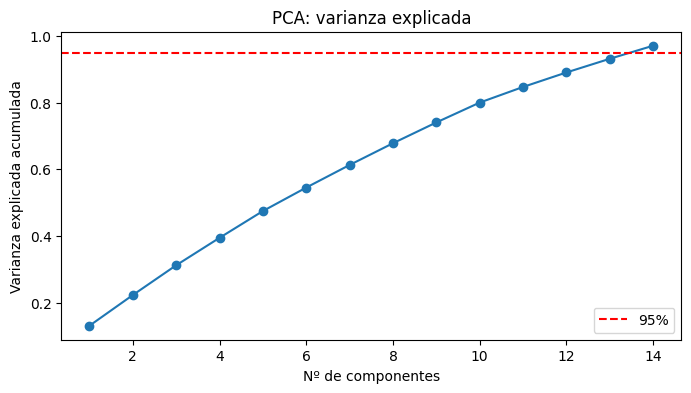

In [23]:
# Elegimos el numero de componentes por varianza explicada (95%)
pca = PCA(0.95, random_state=42).fit(X_train_s)
print("Componentes para explicar el 95% de la varianza:", pca.n_components_)

# Curva de varianza explicada acumulada
var_acum = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(var_acum) + 1), var_acum, "o-")
plt.axhline(0.95, color="red", linestyle="--", label="95%")
plt.xlabel("Nº de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA: varianza explicada")
plt.legend()
plt.show()

In [24]:
# Creamos el dataset transformado con PCA y entrenamos el MISMO tipo de modelo ganador
X_train_pca = pca.transform(X_train_s)
X_test_pca = pca.transform(X_test_s)

# Reinstanciamos el modelo ganador con sus mejores hiperparametros
modelo_pca = grid.best_estimator_.__class__(**grid.best_params_)
# Reaplicamos los ajustes comunes (class_weight / random_state) segun el tipo
if nombre_modelo_ganador in ("logreg", "random_forest"):
    modelo_pca.set_params(class_weight="balanced")
if nombre_modelo_ganador == "logreg":
    modelo_pca.set_params(max_iter=1000)
if nombre_modelo_ganador in ("random_forest", "grad_boosting"):
    modelo_pca.set_params(random_state=42)

modelo_pca.fit(X_train_pca, y_train)
y_pred_pca = modelo_pca.predict(X_test_pca)

print("Recall en test (PCA):", round(recall_score(y_test, y_pred_pca), 3))
print("Recall en test (features seleccionadas):", round(recall_score(y_test, y_pred), 3))
print("\nInforme de clasificacion (PCA):")
print(classification_report(y_test, y_pred_pca))

Recall en test (PCA): 0.717
Recall en test (features seleccionadas): 0.747

Informe de clasificacion (PCA):
              precision    recall  f1-score   support

           0       0.97      0.81      0.89      2198
           1       0.22      0.72      0.34       166

    accuracy                           0.81      2364
   macro avg       0.60      0.77      0.61      2364
weighted avg       0.92      0.81      0.85      2364



**Comentario del extra:**

La PCA nos da un dataset con las componentes que explican el 95% de la varianza, pero **PCA no es exactamente "selección" de features**: crea combinaciones lineales de todas las variables, así que perdemos la interpretabilidad (ya no sabemos "qué variable" importa, sino una mezcla de todas).

Comparando el recall en test, la PCA suele quedar **parecida o algo por debajo** de la selección explícita de features: aquí la varianza no coincide del todo con la capacidad de separar morosos de no morosos (PCA maximiza varianza, no la relación con el target). Por eso, para este problema, **la selección de features gana**: consigue un modelo igual de bueno o mejor, más sencillo (6 variables) y **interpretable**, que es justo lo que pedía el enunciado (el conjunto más sencillo con más potencia).